In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

import warnings
warnings.filterwarnings('ignore')

# Load your exported DAX table
df = pd.read_csv('clv_prep.csv')

# Use 'mixed' to handle the '24-Nov-17' format automatically
df['First_Purchase'] = pd.to_datetime(df['First_Purchase'], format='mixed', dayfirst=True)
df['Last_Purchase'] = pd.to_datetime(df['Last_Purchase'], format='mixed', dayfirst=True)


# 2. Define the Observation Date (One day after the last record in the dataset)
# As discussed, Sept 1, 2018 is the best choice for Olist
observation_date = pd.to_datetime('2018-09-01')

# 3. Create Features (X)
# Recency: Active window in days
df['Recency'] = (df['Last_Purchase'] - df['First_Purchase']).dt.days

# T: Age of customer (How long since their first purchase)
df['T'] = (observation_date - df['First_Purchase']).dt.days

# Avg_Monetary: Average value per order
df['avg_order_value'] = df['Monetary'] / (df['Frequency'] + 1)

# 4. Handle "Frequency" - It is already a feature
# 5. Review Score - Already a feature

In [2]:
df.head()

,customer_unique_id,First_Purchase,Last_Purchase,Frequency,Monetary,Avg_Review_Score,Recency,T,avg_order_value
0,120f875c7db31f3a391a0feacbe05fa5,2017-11-24,2017-11-24,0,62.41,5.0,0,281,62.41
1,e92cf8004da0ba60863ad7d5bd816f5c,2017-11-24,2017-11-24,0,232.90,5.0,0,281,232.90
2,57378b07a6c91c06c139bfff05a246ab,2017-11-24,2017-11-24,0,84.43,5.0,0,281,84.43
3,f5add44bf786bd861fd6108d400cbaa5,2017-11-24,2017-11-24,0,137.85,5.0,0,281,137.85
4,ea1247ecd4957201f8b78eb029ea5dd7,2017-11-24,2017-11-24,0,51.20,5.0,0,281,51.20


In [3]:
# Check for null values in each column
print(df.isnull().sum())

customer_unique_id      0
First_Purchase          0
Last_Purchase           0
Frequency               0
Monetary                2
Avg_Review_Score      671
Recency                 0
T                       0
avg_order_value         2
dtype: int64


In [4]:
# View records where either Monetary or Review Score is missing
abnormal_records = df[df['Monetary'].isnull() | df['Avg_Review_Score'].isnull()]

# Display the first few rows of these abnormal records
abnormal_records.head(10)

,customer_unique_id,First_Purchase,Last_Purchase,Frequency,Monetary,Avg_Review_Score,Recency,T,avg_order_value
2431,9925e1d7dff0d807355599dee04830ab,2018-05-15,2018-05-15,0,NaN,5.0,0,109,NaN
18639,f54cea27c80dc09bfe07b1cf1e01b845,2018-04-22,2018-04-22,0,NaN,5.0,0,132,NaN
89932,7f3a72e8f988c6e735ba118d54f47458,2017-05-11,2017-05-11,0,102.03,NaN,0,478,102.03
89933,6ac6902b78ed854e42f75c8e25234e8c,2018-08-27,2018-08-27,0,53.48,NaN,0,5,53.48
89934,0946262550402fc07495e24ad9f252f2,2018-04-05,2018-04-05,0,131.17,NaN,0,149,131.17
89935,30de122d775af047eb43340af4ba6159,2017-05-14,2017-05-14,0,153.90,NaN,0,475,153.90
89936,5400394e71d0e31eff5a35aa40fb26ac,2018-02-26,2018-02-26,0,90.24,NaN,0,187,90.24
89937,9049685052da8ea435727689c67b81c9,2017-04-24,2017-04-24,0,82.88,NaN,0,495,82.88
89938,b5b17698671a4c3822309b13d4f16f9e,2018-02-04,2018-02-04,0,77.28,NaN,0,209,77.28
89939,4bb7d9f700ca1724ed6ec873680e4220,2018-07-10,2018-07-10,0,27.39,NaN,0,53,27.39


In [5]:
df_model = df.dropna(subset=['Monetary', 'Avg_Review_Score','avg_order_value'])

In [6]:
# View records where either Monetary or Review Score is missing
abnormal_records = df[(df['Monetary']==0)]

# Display the first few rows of these abnormal records
abnormal_records.head(10)

,customer_unique_id,First_Purchase,Last_Purchase,Frequency,Monetary,Avg_Review_Score,Recency,T,avg_order_value


In [7]:
rfm_features = ['Recency', 'Frequency', 'Monetary']

quantiles = df_model[rfm_features].quantile(q=[0.25, 0.5, 0.75])
quantiles = quantiles.to_dict()

print(quantiles)

{'Recency': {0.25: 0.0, 0.5: 0.0, 0.75: 0.0}, 'Frequency': {0.25: 0.0, 0.5: 0.0, 0.75: 0.0}, 'Monetary': {0.25: 63.1, 0.5: 107.78, 0.75: 183.4}}


In [8]:
def RScoring(x, p, d):
    if x <= d[p][0.25]:
        return 4 
    elif x <= d[p][0.50]:
        return 3
    elif x <= d[p][0.75]: 
        return 2
    else:
        return 1  


def FnMScoring(x, p, d):
    if x <= d[p][0.25]:
        return 1  
    elif x <= d[p][0.50]:
        return 2
    elif x <= d[p][0.75]: 
        return 3
    else:
        return 4  

In [9]:
#Calculate Add R, F and M segment value columns in the existing dataset to show R, F and M segment values
df_model['R'] = df_model['Recency'].apply(RScoring, args=('Recency',quantiles,))
df_model['F'] = df_model['Frequency'].apply(FnMScoring, args=('Frequency',quantiles,))
df_model['M'] = df_model['Monetary'].apply(FnMScoring, args=('Monetary',quantiles,))
df_model.head()

,customer_unique_id,First_Purchase,Last_Purchase,Frequency,Monetary,Avg_Review_Score,Recency,T,avg_order_value,R,F,M
0,120f875c7db31f3a391a0feacbe05fa5,2017-11-24,2017-11-24,0,62.41,5.0,0,281,62.41,4,1,1
1,e92cf8004da0ba60863ad7d5bd816f5c,2017-11-24,2017-11-24,0,232.90,5.0,0,281,232.90,4,1,4
2,57378b07a6c91c06c139bfff05a246ab,2017-11-24,2017-11-24,0,84.43,5.0,0,281,84.43,4,1,2
3,f5add44bf786bd861fd6108d400cbaa5,2017-11-24,2017-11-24,0,137.85,5.0,0,281,137.85,4,1,3
4,ea1247ecd4957201f8b78eb029ea5dd7,2017-11-24,2017-11-24,0,51.20,5.0,0,281,51.20,4,1,1


In [10]:
#Calculate and Add RFMGroup value column showing combined concatenated score of RFM
df_model['RFMGroup'] = df_model.R.map(str) + df_model.F.map(str) + df_model.M.map(str)

#Calculate and Add RFMScore value column showing total sum of RFMGroup values
df_model['RFMScore'] = df_model[['R', 'F', 'M']].sum(axis = 1)
df_model.head()

,customer_unique_id,First_Purchase,Last_Purchase,Frequency,Monetary,Avg_Review_Score,Recency,T,avg_order_value,R,F,M,RFMGroup,RFMScore
0,120f875c7db31f3a391a0feacbe05fa5,2017-11-24,2017-11-24,0,62.41,5.0,0,281,62.41,4,1,1,411,6
1,e92cf8004da0ba60863ad7d5bd816f5c,2017-11-24,2017-11-24,0,232.90,5.0,0,281,232.90,4,1,4,414,9
2,57378b07a6c91c06c139bfff05a246ab,2017-11-24,2017-11-24,0,84.43,5.0,0,281,84.43,4,1,2,412,7
3,f5add44bf786bd861fd6108d400cbaa5,2017-11-24,2017-11-24,0,137.85,5.0,0,281,137.85,4,1,3,413,8
4,ea1247ecd4957201f8b78eb029ea5dd7,2017-11-24,2017-11-24,0,51.20,5.0,0,281,51.20,4,1,1,411,6


In [11]:
#Validate the data for RFMGroup = 112
df_model[df_model['RFMGroup']=='112'].sort_values('Monetary', ascending=False).reset_index().head()

,index,customer_unique_id,First_Purchase,Last_Purchase,Frequency,Monetary,Avg_Review_Score,Recency,T,avg_order_value,R,F,M,RFMGroup,RFMScore


<Axes: xlabel='Monetary', ylabel='Density'>

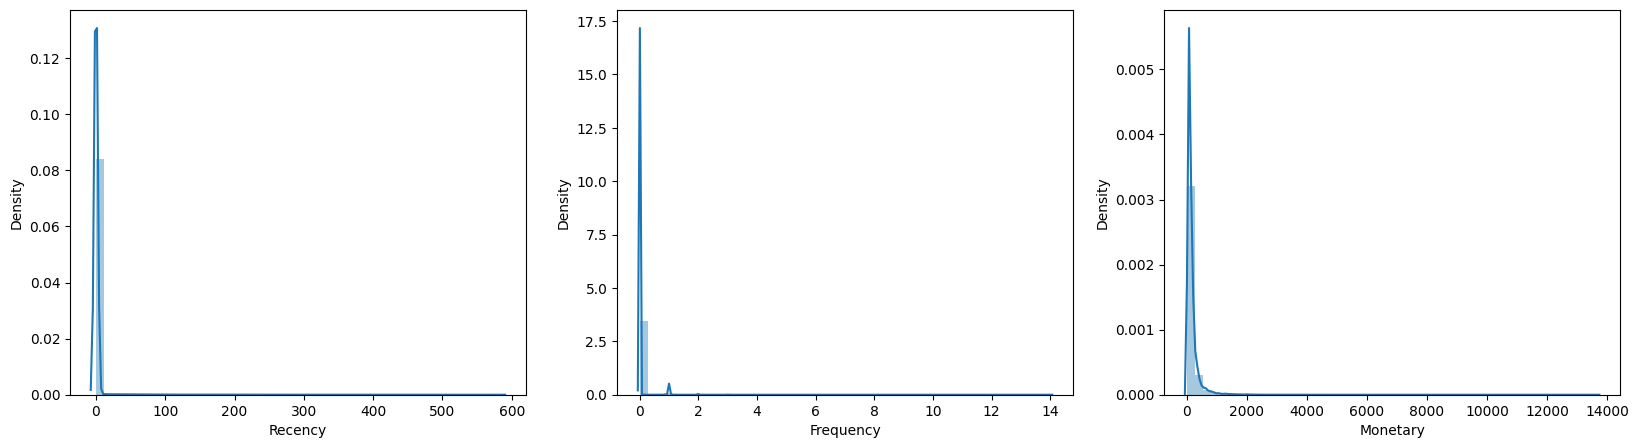

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
#Plot data distribution
plt.figure(figsize=(20,5))

plt.subplot(1,3,1)
sns.distplot(df_model['Recency'])

plt.subplot(1,3,2)
sns.distplot(df_model['Frequency'])

plt.subplot(1,3,3)
sns.distplot(df_model['Monetary'])

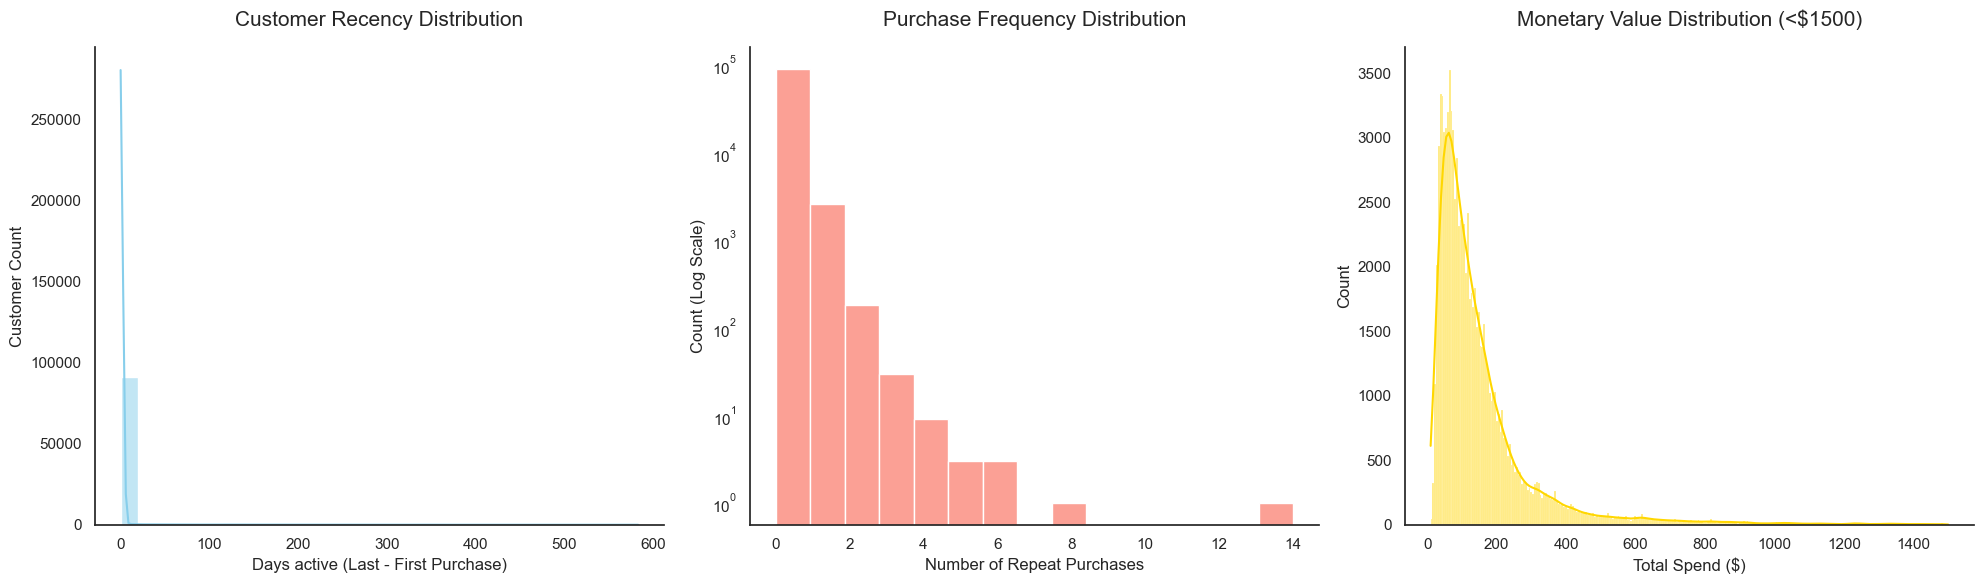

In [13]:
# 1. Set a professional style
sns.set_theme(style="white", palette="viridis")
plt.figure(figsize=(20, 6))

# --- Plot 1: Recency ---
plt.subplot(1, 3, 1)
sns.histplot(df_model['Recency'], kde=True, color="skyblue", bins=30)
plt.title('Customer Recency Distribution', fontsize=15, pad=15)
plt.xlabel('Days active (Last - First Purchase)')
plt.ylabel('Customer Count')
sns.despine() # Removes the top and right borders

# --- Plot 2: Frequency ---
plt.subplot(1, 3, 2)
# Log scale helps visualize the small number of repeat customers
sns.histplot(df_model['Frequency'], kde=False, color="salmon", bins=15)
plt.title('Purchase Frequency Distribution', fontsize=15, pad=15)
plt.xlabel('Number of Repeat Purchases')
plt.yscale('log') # Use log scale because 0 is so dominant
plt.ylabel('Count (Log Scale)')
sns.despine()

# --- Plot 3: Monetary ---
plt.subplot(1, 3, 3)
# Limiting x-axis to 1500 to ignore extreme outliers for a better visual
sns.histplot(df_model[df_model['Monetary'] < 1500]['Monetary'], kde=True, color="gold")
plt.title('Monetary Value Distribution (<$1500)', fontsize=15, pad=15)
plt.xlabel('Total Spend ($)')
sns.despine()

plt.tight_layout()
plt.show()

The data is extremely "left-skewed," with almost all customers clustered at zero days. This proves that the vast majority of customers never return after their first purchase. The "Active Window" for most users is less than 24 hours

Even using a Logarithmic Scale, the "Zero Repeat Purchase" bar dominates the chart. While a tiny fraction of "Super-Users" has made up to 14 repeat purchases, they represent less than 3% of the total base. Olist relies on a "One-and-Done" transactional model.

Most transactions are concentrated in the low-value range ($50 - $200). However, the presence of a "long tail" indicates that revenue is driven by high-ticket items rather than high-frequency shopping. There is a clear disconnect between loyalty (Frequency) and value (Monetary)

In [14]:
rfm_log = df_model[['Recency', 'Frequency', 'Monetary']].apply(np.log1p, axis=1).round(3)

rfm_log.head()

,Recency,Frequency,Monetary
0,0.0,0.0,4.150
1,0.0,0.0,5.455
2,0.0,0.0,4.448
3,0.0,0.0,4.933
4,0.0,0.0,3.955


In [15]:
rfm_log.head()

,Recency,Frequency,Monetary
0,0.0,0.0,4.150
1,0.0,0.0,5.455
2,0.0,0.0,4.448
3,0.0,0.0,4.933
4,0.0,0.0,3.955


<Axes: xlabel='Monetary', ylabel='Density'>

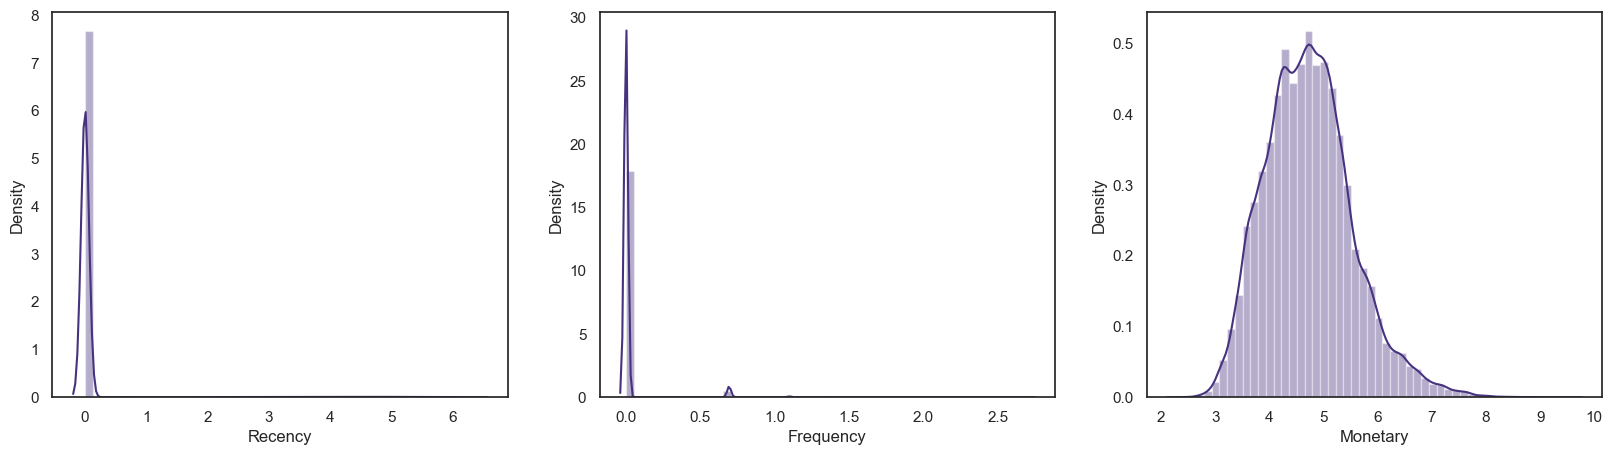

In [16]:
#Plot data distribution after log transformation
plt.figure(figsize=(20,5))

plt.subplot(1,3,1)
sns.distplot(rfm_log['Recency'])

plt.subplot(1,3,2)
sns.distplot(rfm_log['Frequency'])

plt.subplot(1,3,3)
sns.distplot(rfm_log['Monetary'])

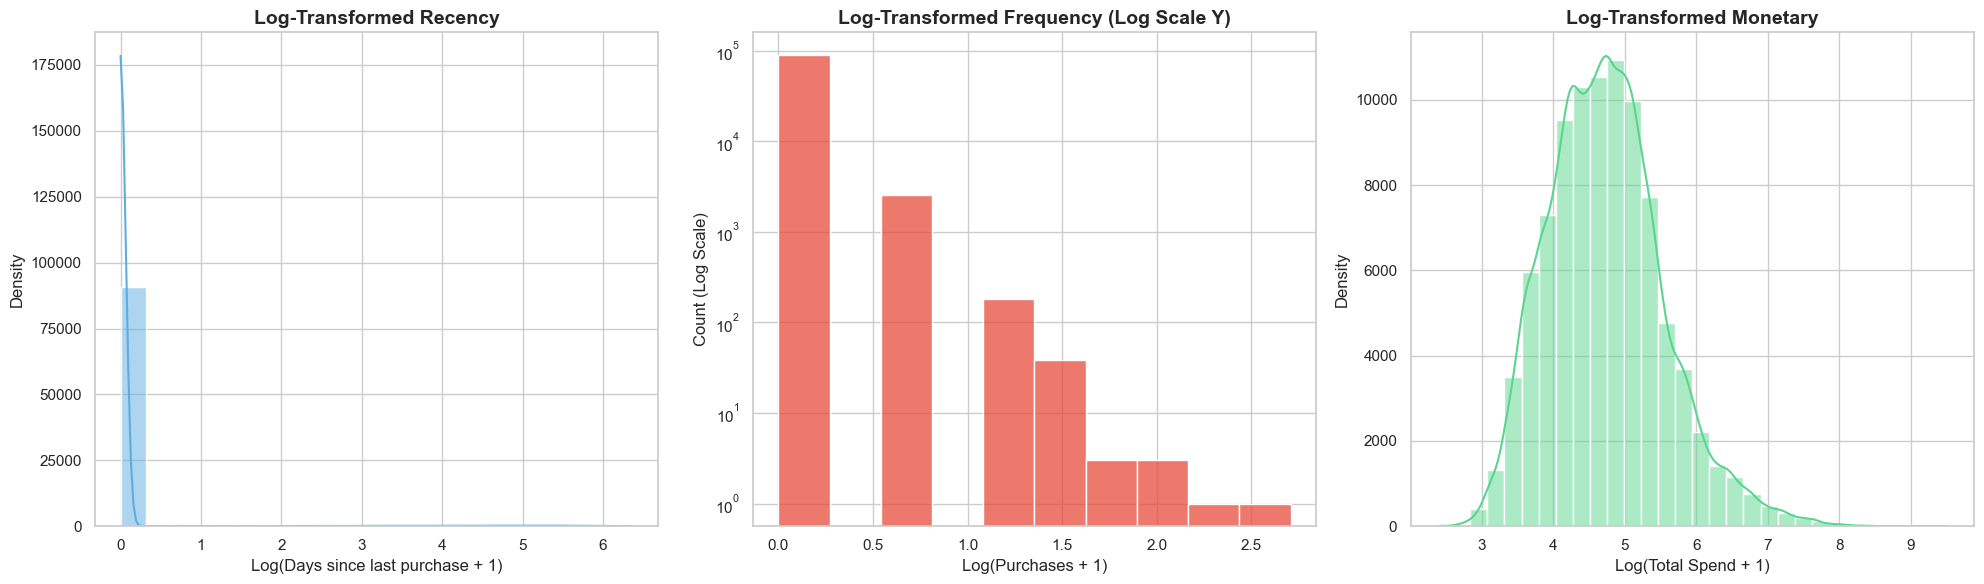

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Set a clean, professional aesthetic
sns.set_style("whitegrid")
plt.figure(figsize=(20, 6))

# --- Plot 1: Recency (Log) ---
plt.subplot(1, 3, 1)
sns.histplot(rfm_log['Recency'], kde=True, color="#5DADE2", bins=20)
plt.title('Log-Transformed Recency', fontsize=14, fontweight='bold')
plt.xlabel('Log(Days since last purchase + 1)')
plt.ylabel('Density')

# --- Plot 2: Frequency (Log) ---
plt.subplot(1, 3, 2)
# Using a log scale on the Y-axis helps show the small counts for repeat buyers
sns.histplot(rfm_log['Frequency'], kde=False, color="#E74C3C", bins=10)
plt.yscale('log') 
plt.title('Log-Transformed Frequency (Log Scale Y)', fontsize=14, fontweight='bold')
plt.xlabel('Log(Purchases + 1)')
plt.ylabel('Count (Log Scale)')

# --- Plot 3: Monetary (Log) ---
plt.subplot(1, 3, 3)
sns.histplot(rfm_log['Monetary'], kde=True, color="#58D68D", bins=30)
plt.title('Log-Transformed Monetary', fontsize=14, fontweight='bold')
plt.xlabel('Log(Total Spend + 1)')
plt.ylabel('Density')

plt.tight_layout()
plt.show()

In [18]:
df_model.head()

,customer_unique_id,First_Purchase,Last_Purchase,Frequency,Monetary,Avg_Review_Score,Recency,T,avg_order_value,R,F,M,RFMGroup,RFMScore
0,120f875c7db31f3a391a0feacbe05fa5,2017-11-24,2017-11-24,0,62.41,5.0,0,281,62.41,4,1,1,411,6
1,e92cf8004da0ba60863ad7d5bd816f5c,2017-11-24,2017-11-24,0,232.90,5.0,0,281,232.90,4,1,4,414,9
2,57378b07a6c91c06c139bfff05a246ab,2017-11-24,2017-11-24,0,84.43,5.0,0,281,84.43,4,1,2,412,7
3,f5add44bf786bd861fd6108d400cbaa5,2017-11-24,2017-11-24,0,137.85,5.0,0,281,137.85,4,1,3,413,8
4,ea1247ecd4957201f8b78eb029ea5dd7,2017-11-24,2017-11-24,0,51.20,5.0,0,281,51.20,4,1,1,411,6


In [19]:
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)

In [20]:
rfm_scaled = pd.DataFrame(rfm_scaled, index=df_model.index, columns= rfm_log.columns)
rfm_scaled.head()

,Recency,Frequency,Monetary
0,-0.141386,-0.17293,-0.717627
1,-0.141386,-0.17293,0.894559
2,-0.141386,-0.17293,-0.349481
3,-0.141386,-0.17293,0.249684
4,-0.141386,-0.17293,-0.958529


In [21]:
#Build K Means clustering model using K=3
kmean_model = KMeans(n_clusters=3, init='k-means++', max_iter=1000, random_state=20)
kmean_model.fit(rfm_scaled)

#find the clusters for the records given in our dataset
df_model['Cluster'] = kmean_model.labels_

#check the datset
df_model.head()

,customer_unique_id,First_Purchase,Last_Purchase,Frequency,Monetary,Avg_Review_Score,Recency,T,avg_order_value,R,F,M,RFMGroup,RFMScore,Cluster
0,120f875c7db31f3a391a0feacbe05fa5,2017-11-24,2017-11-24,0,62.41,5.0,0,281,62.41,4,1,1,411,6,0
1,e92cf8004da0ba60863ad7d5bd816f5c,2017-11-24,2017-11-24,0,232.90,5.0,0,281,232.90,4,1,4,414,9,2
2,57378b07a6c91c06c139bfff05a246ab,2017-11-24,2017-11-24,0,84.43,5.0,0,281,84.43,4,1,2,412,7,0
3,f5add44bf786bd861fd6108d400cbaa5,2017-11-24,2017-11-24,0,137.85,5.0,0,281,137.85,4,1,3,413,8,2
4,ea1247ecd4957201f8b78eb029ea5dd7,2017-11-24,2017-11-24,0,51.20,5.0,0,281,51.20,4,1,1,411,6,0


In [22]:
bins = [2, 4, 6, 8, 10, 12]
labels = ['3-4 (Very Low)', '5-6 (Low)', '7-8 (Medium)', '9-10 (High)', '11-12 (Platinum)']

df_model['Score_Group'] = pd.cut(df_model['RFMScore'], bins=bins, labels=labels)

group_counts = df_model['Score_Group'].value_counts().sort_index()
print(group_counts)

diagnostic_summary = df_model.groupby('Score_Group').agg({
    'Monetary': 'mean',
    'Frequency': 'mean',
    'Recency': 'mean',
    'RFMScore': 'count'
}).rename(columns={'RFMScore': 'Customer_Count'})

print(diagnostic_summary)


Score_Group
3-4 (Very Low)          0
5-6 (Low)           23170
7-8 (Medium)        46010
9-10 (High)         22873
11-12 (Platinum)      680
Name: count, dtype: int64
                    Monetary  Frequency   Recency  Customer_Count
Score_Group                                                      
3-4 (Very Low)           NaN        NaN       NaN               0
5-6 (Low)          43.626370   0.001295  0.097583           23170
7-8 (Medium)      112.265339   0.014562  1.590198           46010
9-10 (High)       392.072505   0.075067  7.341538           22873
11-12 (Platinum)  308.010647   1.029412  0.000000             680


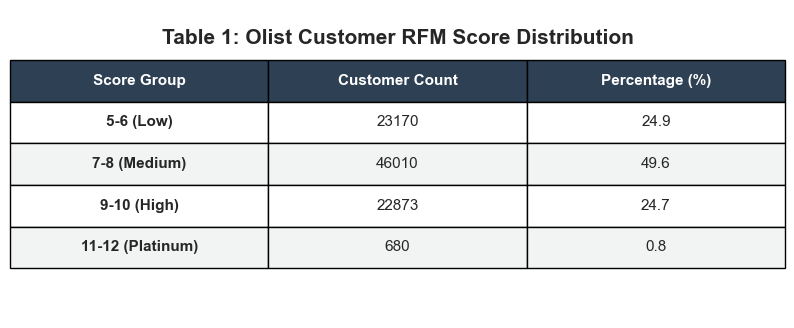

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

summary_data = {
    "Score Group": ['5-6 (Low)', '7-8 (Medium)', '9-10 (High)', '11-12 (Platinum)'],
    "Customer Count": [23170, 46010, 22873, 680],
    "Percentage (%)": [24.9, 49.6, 24.7, 0.8]
}
df_table1 = pd.DataFrame(summary_data)

fig, ax = plt.subplots(figsize=(10, 4))
ax.axis('off')

header_color = '#2E4053'
row_colors = ['#F2F4F4', 'white']

table = ax.table(
    cellText=df_table1.values,
    colLabels=df_table1.columns,
    cellLoc='center', loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 2.5)

for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_text_props(weight='bold', color='white')
        cell.set_facecolor(header_color)
    else:
        cell.set_facecolor(row_colors[row % 2])
        if col == 0: cell.set_text_props(weight='bold')

plt.title("Table 1: Olist Customer RFM Score Distribution", fontsize=15, fontweight='bold', pad=20,y=0.8)
plt.savefig("RFM_Score_Distribution_Table.png", dpi=300, bbox_inches='tight', pad_inches=0.5)
plt.show()


In [24]:
df_model.head()

,customer_unique_id,First_Purchase,Last_Purchase,Frequency,Monetary,Avg_Review_Score,Recency,T,avg_order_value,R,F,M,RFMGroup,RFMScore,Cluster,Score_Group
0,120f875c7db31f3a391a0feacbe05fa5,2017-11-24,2017-11-24,0,62.41,5.0,0,281,62.41,4,1,1,411,6,0,5-6 (Low)
1,e92cf8004da0ba60863ad7d5bd816f5c,2017-11-24,2017-11-24,0,232.90,5.0,0,281,232.90,4,1,4,414,9,2,9-10 (High)
2,57378b07a6c91c06c139bfff05a246ab,2017-11-24,2017-11-24,0,84.43,5.0,0,281,84.43,4,1,2,412,7,0,7-8 (Medium)
3,f5add44bf786bd861fd6108d400cbaa5,2017-11-24,2017-11-24,0,137.85,5.0,0,281,137.85,4,1,3,413,8,2,7-8 (Medium)
4,ea1247ecd4957201f8b78eb029ea5dd7,2017-11-24,2017-11-24,0,51.20,5.0,0,281,51.20,4,1,1,411,6,0,5-6 (Low)


In [25]:
Loyalty_Labels = ['Bronze', 'Silver', 'Gold', 'Platinum']
df_model['RFM_Loyalty_Level'] = pd.qcut(df_model.RFMScore, q=4, labels=Loyalty_Labels)
print(df_model.groupby('RFM_Loyalty_Level')['RFMScore'].agg(['min', 'max']))

                   min  max
RFM_Loyalty_Level          
Bronze               6    7
Silver               8    8
Gold                 9    9
Platinum            10   12


In [26]:
df_model['RFM_Loyalty_Level'].value_counts()

RFM_Loyalty_Level
Bronze      46280
Silver      22900
Gold        22779
Platinum      774
Name: count, dtype: int64

In [27]:
analysis = df_model.groupby('RFM_Loyalty_Level').agg({
    'Avg_Review_Score': 'mean',
    'Monetary': 'mean',
    'customer_unique_id': 'count'
}).rename(columns={'customer_unique_id': 'Customer_Count'})

print(analysis)

                   Avg_Review_Score    Monetary  Customer_Count
RFM_Loyalty_Level                                              
Bronze                     4.169382   63.600995           46280
Silver                     4.124571  141.165816           22900
Gold                       4.009101  393.328737           22779
Platinum                   3.910207  281.248527             774


In [28]:
df_model

,customer_unique_id,First_Purchase,Last_Purchase,Frequency,Monetary,Avg_Review_Score,Recency,T,avg_order_value,R,F,M,RFMGroup,RFMScore,Cluster,Score_Group,RFM_Loyalty_Level
0,120f875c7db31f3a391a0feacbe05fa5,2017-11-24,2017-11-24,0,62.41,5.00,0,281,62.4100,4,1,1,411,6,0,5-6 (Low),Bronze
1,e92cf8004da0ba60863ad7d5bd816f5c,2017-11-24,2017-11-24,0,232.90,5.00,0,281,232.9000,4,1,4,414,9,2,9-10 (High),Gold
2,57378b07a6c91c06c139bfff05a246ab,2017-11-24,2017-11-24,0,84.43,5.00,0,281,84.4300,4,1,2,412,7,0,7-8 (Medium),Bronze
3,f5add44bf786bd861fd6108d400cbaa5,2017-11-24,2017-11-24,0,137.85,5.00,0,281,137.8500,4,1,3,413,8,2,7-8 (Medium),Silver
4,ea1247ecd4957201f8b78eb029ea5dd7,2017-11-24,2017-11-24,0,51.20,5.00,0,281,51.2000,4,1,1,411,6,0,5-6 (Low),Bronze
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
93401,35ecdf6858edc6427223b64804cf028e,2017-08-05,2018-03-31,4,603.90,3.80,238,392,120.7800,1,4,4,144,9,1,9-10 (High),Gold
93402,ec7f1811826ab04a27a92197bc40c888,2017-11-02,2017-12-19,3,556.94,4.75,47,303,139.2350,1,4,4,144,9,1,9-10 (High),Gold
93403,a1874c5550d2f0bc14cc122164603713,2017-06-30,2018-05-23,3,790.67,4.25,327,428,197.6675,1,4,4,144,9,1,9-10 (High),Gold
93404,9cc5a07f169a1606fd347a56683e6ea6,2017-12-13,2018-08-22,3,419.25,5.00,252,262,104.8125,1,4,4,144,9,1,9-10 (High),Gold


In [29]:
df_model['Purchase_Month'] = df_model['First_Purchase'].dt.to_period('M').astype(str)

monthly_trend = df_model.groupby('Purchase_Month').agg({
    'RFMScore': 'mean',
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean'
}).reset_index()

monthly_trend = monthly_trend[monthly_trend['Purchase_Month'] < '2018-09']

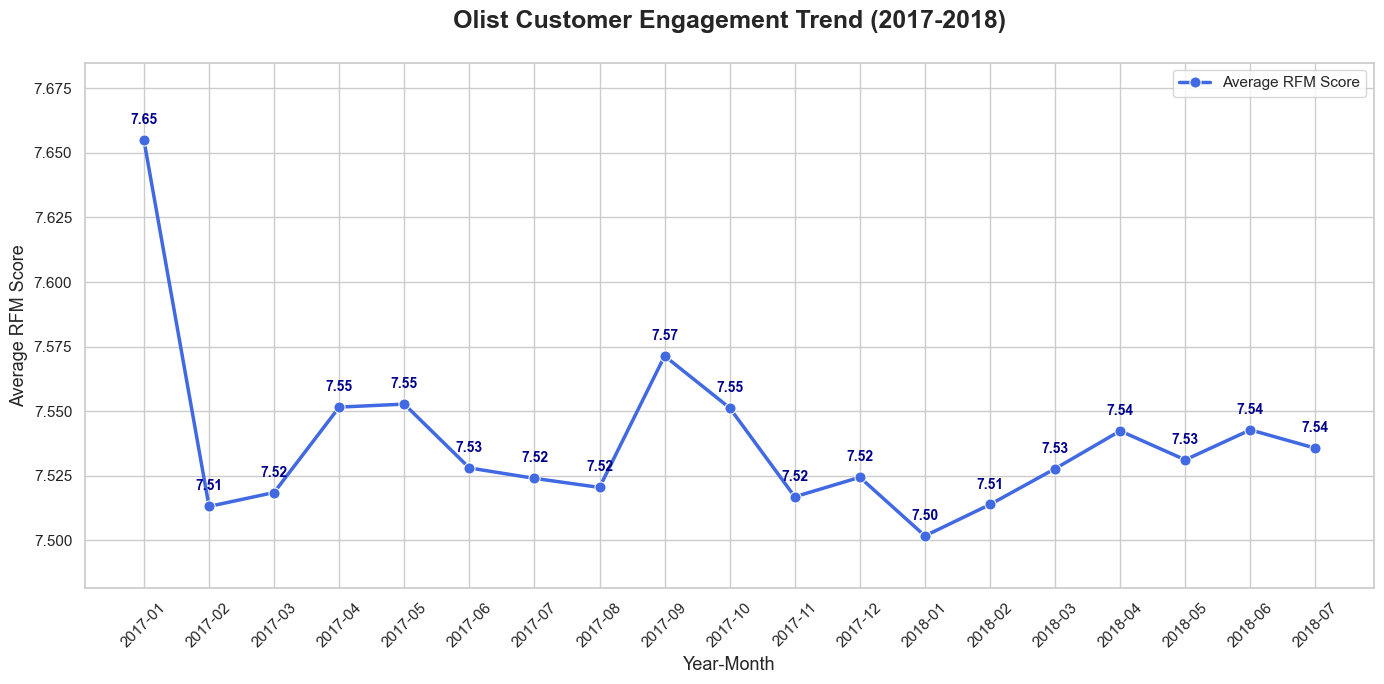

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

monthly_trend_clean = monthly_trend[monthly_trend['Purchase_Month'] < '2018-08']

sns.set_style("whitegrid")
plt.figure(figsize=(14, 7))

sns.lineplot(data=monthly_trend_clean, x='Purchase_Month', y='RFMScore', 
             marker='o', markersize=8, color='royalblue', linewidth=2.5, label='Average RFM Score')

plt.title('Olist Customer Engagement Trend (2017-2018)', fontsize=18, fontweight='bold', pad=25)
plt.xlabel('Year-Month', fontsize=13) 
plt.ylabel('Average RFM Score', fontsize=13)

plt.xticks(rotation=45)

for x, y in zip(monthly_trend_clean['Purchase_Month'], monthly_trend_clean['RFMScore']):
    plt.text(x, y + 0.005, f'{y:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold', color='darkblue')

plt.ylim(monthly_trend_clean['RFMScore'].min() - 0.02, monthly_trend_clean['RFMScore'].max() + 0.03)

plt.tight_layout()

plt.savefig("Olist_Engagement_Trend.png", dpi=300, bbox_inches='tight')
plt.show()


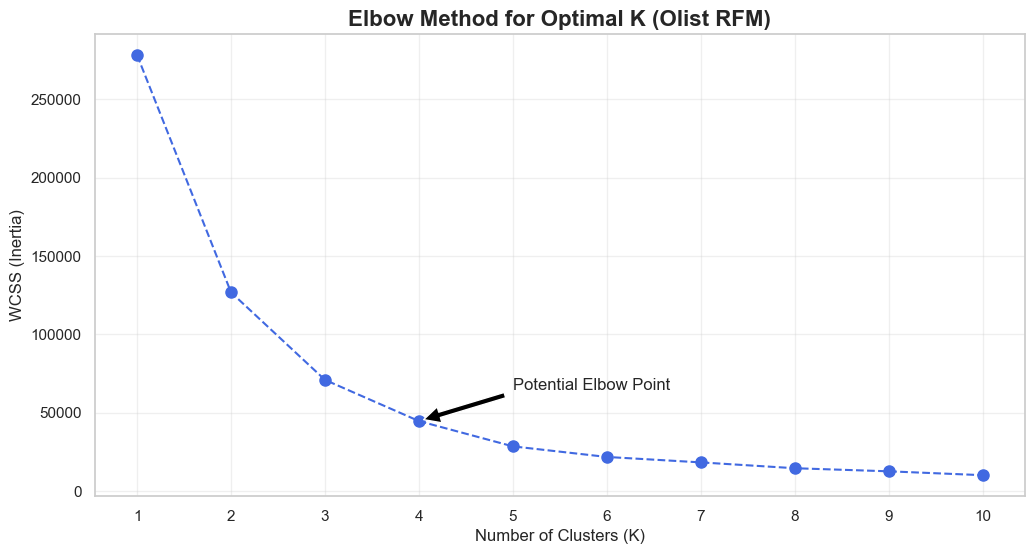

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

rfm_log = df_model[['Recency', 'Frequency', 'Monetary']].apply(lambda x: np.log(x + 1))
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)

wcss = []
k_range = range(1, 11) 

for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    kmeans.fit(rfm_scaled)
    wcss.append(kmeans.inertia_) 

plt.figure(figsize=(12, 6))
plt.plot(k_range, wcss, marker='o', linestyle='--', color='royalblue', markersize=8)

plt.title('Elbow Method for Optimal K (Olist RFM)', fontsize=16, fontweight='bold')
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('WCSS (Inertia)', fontsize=12)
plt.xticks(k_range)
plt.grid(True, alpha=0.3)

plt.annotate('Potential Elbow Point', xy=(4, wcss[3]), xytext=(5, wcss[3]+20000),
             arrowprops=dict(facecolor='black', shrink=0.05), fontsize=12)
plt.savefig("Elbow.png", dpi=300, bbox_inches='tight', pad_inches=0.5)
plt.show()


In [32]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, init='k-means++', random_state=42)
df_model['Cluster'] = kmeans.fit_predict(rfm_scaled)

cluster_stats = df_model.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': ['mean', 'count']
}).round(2)

cluster_stats.columns = ['Avg_Recency', 'Avg_Frequency', 'Avg_Monetary', 'Customer_Count']
cluster_stats = cluster_stats.sort_values(by='Avg_Monetary', ascending=False)

print("--- Olist K-Means (K=4) Cluster Profiles ---")
print(cluster_stats)

cluster_stats['Revenue_Share'] = (cluster_stats['Avg_Monetary'] * cluster_stats['Customer_Count'])
total_rev = cluster_stats['Revenue_Share'].sum()
cluster_stats['Revenue_Percentage'] = (cluster_stats['Revenue_Share'] / total_rev * 100).round(2)

print("\n--- Revenue Contribution Analysis ---")
print(cluster_stats[['Customer_Count', 'Revenue_Percentage']])


--- Olist K-Means (K=4) Cluster Profiles ---
         Avg_Recency  Avg_Frequency  Avg_Monetary  Customer_Count
Cluster                                                          
1             139.35           1.16        316.72            1736
3               1.35           1.04        296.22            1067
0               0.00           0.00        277.89           40063
2               0.00           0.00         67.26           49867

--- Revenue Contribution Analysis ---
         Customer_Count  Revenue_Percentage
Cluster                                    
1                  1736                3.58
3                  1067                2.06
0                 40063               72.51
2                 49867               21.85


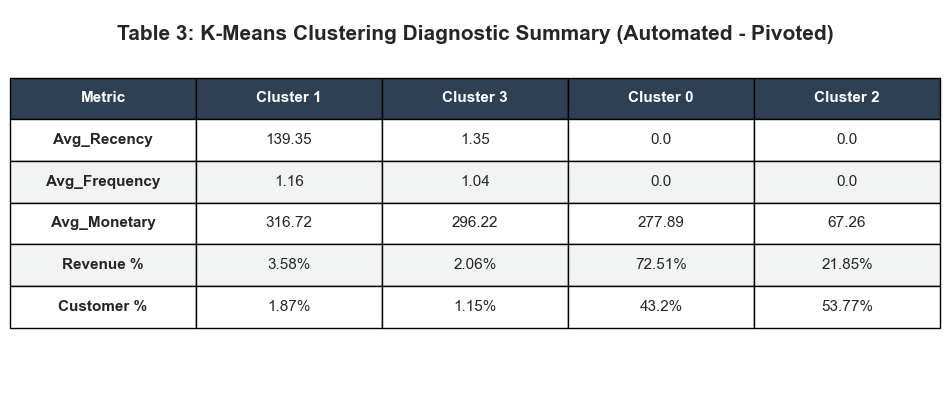

In [33]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Sort and clear cluster names as before
df_k_calc = cluster_stats.sort_values(by='Avg_Monetary', ascending=False).reset_index()
df_k_calc['Cluster'] = 'Cluster ' + df_k_calc['Cluster'].astype(str)

# 2. Compute both metric percentages
total_revenue = (df_k_calc['Avg_Monetary'] * df_k_calc['Customer_Count']).sum()
df_k_calc['Revenue %'] = ((df_k_calc['Avg_Monetary'] * df_k_calc['Customer_Count']) / total_revenue * 100).round(2).astype(str) + '%'

total_customers = df_k_calc['Customer_Count'].sum()
df_k_calc['Customer %'] = ((df_k_calc['Customer_Count'] / total_customers) * 100).round(2).astype(str) + '%'

# 3. Select metrics (strictly omitting 'Customer_Count')
metrics_df = df_k_calc[['Cluster', 'Avg_Recency', 'Avg_Frequency', 'Avg_Monetary', 'Revenue %', 'Customer %']]

# 4. Pivot/Transpose the layout
table_display_df = metrics_df.set_index('Cluster').T.reset_index()
table_display_df.rename(columns={'index': 'Metric'}, inplace=True)

# 5. Generate visualization
fig, ax = plt.subplots(figsize=(12, 5))
ax.axis('off')

header_color = '#2E4053' 
row_colors = ['#F2F4F4', 'white']

table = ax.table(
    cellText=table_display_df.values,
    colLabels=table_display_df.columns,
    cellLoc='center', 
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 2.5)

# Format rows dynamically based on the updated structure
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_text_props(weight='bold', color='white')
        cell.set_facecolor(header_color)
    else:
        cell.set_facecolor(row_colors[row % 2])
        if col == 0: 
            cell.set_text_props(weight='bold')
        
        # Currency formatting for the 'Avg_Monetary' row (now index 3 in our table layout)
        if row == 3 and col > 0:
            val = float(table_display_df.iloc[row-1, col])
            cell.get_text().set_text(f"{val:,.2f}")

plt.title("Table 3: K-Means Clustering Diagnostic Summary (Automated - Pivoted)", 
          fontsize=15, fontweight='bold', pad=20, y=0.85)

plt.savefig("Olist_KMeans_Diagnostic_Table_Final.png", dpi=300, bbox_inches='tight', pad_inches=0.5)
plt.show()

